# Preprocesamiento y Mapeo de Categorías
## Clasificador de Noticias: Actualidad vs Interés General

Este notebook realiza el preprocesamiento de datos y mapea las categorías originales a dos clases binarias.

**Objetivos:**
1. Cargar el dataset combinado
2. Definir mapeo de categorías a clases binarias
3. Limpiar duplicados
4. Normalizar texto
5. Guardar dataset preprocesado

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("Librerías importadas exitosamente")

Librerías importadas exitosamente


## 1. Cargar Dataset Combinado

In [2]:
# Cargar dataset combinado del EDA
df = pd.read_csv('../data/processed/combined_raw.csv')
print(f"Dataset cargado: {len(df):,} registros")
print(f"\nColumnas: {df.columns.tolist()}")
print(f"\nPrimeras filas:")
display(df.head())

Dataset cargado: 210,409 registros

Columnas: ['doc_id', 'category', 'subcategory', 'title', 'source', 'title_length', 'word_count']

Primeras filas:


,doc_id,category,subcategory,title,source,title_length,word_count
0,N88753,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...",MIND,70,11
1,N45436,news,newsscienceandtechnology,Walmart Slashes Prices on Last-Generation iPads,MIND,47,6
2,N23144,health,weightloss,50 Worst Habits For Belly Fat,MIND,29,6
3,N86255,health,medical,Dispose of unwanted prescription drugs during ...,MIND,69,11
4,N93187,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,MIND,63,12


## 2. Definir Mapeo de Categorías a Clases Binarias

### Definición de clases:

**CLASE 0 - ACTUALIDAD (Current News):**
Noticias de eventos actuales, política, economía, asuntos mundiales, ciencia y tecnología de interés noticioso.

**CLASE 1 - INTERÉS GENERAL (General Interest):**
Contenido de entretenimiento, deportes, estilo de vida, salud, viajes, etc.

In [3]:
# Definir mapeo de categorías
# Clase 0: Actualidad (Current News)
# Clase 1: Interés General (General Interest)

actualidad_categories = {
    # MIND categories
    'news',
    'finance',
    'weather',
    'northamerica',
    'middleeast',
    
    # GOOGLE categories
    'World',
    'U.S.',
    'Business',
    'Science',
    'Technology'  # Incluido en actualidad por ser noticias de tecnología
}

interes_general_categories = {
    # MIND categories
    'sports',
    'lifestyle',
    'video',
    'foodanddrink',
    'autos',
    'health',
    'tv',
    'music',
    'entertainment',
    'movies',
    'kids',
    'travel',
    'games',
    
    # GOOGLE categories
    'Sport',
    'Entertainment',
    'Health'
}

def map_to_binary_class(category):
    """
    Mapea una categoría a clase binaria.
    0 = Actualidad (Current News)
    1 = Interés General (General Interest)
    """
    if category in actualidad_categories:
        return 0
    elif category in interes_general_categories:
        return 1
    else:
        # Categorías no mapeadas (si existen)
        return -1

# Aplicar mapeo
df['label'] = df['category'].apply(map_to_binary_class)

# Verificar si hay categorías no mapeadas
unmapped = df[df['label'] == -1]
if len(unmapped) > 0:
    print(f"⚠️ ADVERTENCIA: {len(unmapped)} registros con categorías no mapeadas:")
    print(unmapped['category'].value_counts())
else:
    print("✓ Todas las categorías mapeadas exitosamente")

# Crear columna con nombre de clase legible
df['class_name'] = df['label'].map({0: 'Actualidad', 1: 'Interés General'})

print(f"\nDistribución de clases:")
print(df['label'].value_counts().sort_index())
print(f"\nPorcentaje:")
print((df['label'].value_counts(normalize=True).sort_index() * 100).round(2))

✓ Todas las categorías mapeadas exitosamente

Distribución de clases:
label
0     82823
1    127586
Name: count, dtype: int64

Porcentaje:
label
0    39.36
1    60.64
Name: proportion, dtype: float64


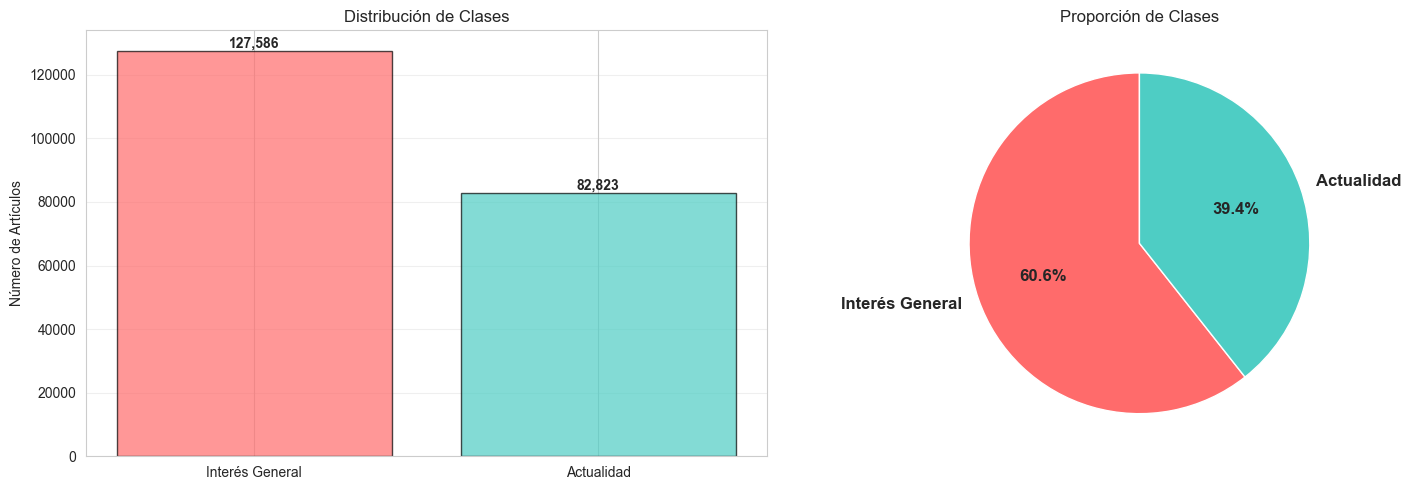

Gráfico guardado en: ../results/class_distribution.png


In [4]:
# Visualizar distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de barras
class_counts = df['class_name'].value_counts()
axes[0].bar(class_counts.index, class_counts.values, color=['#FF6B6B', '#4ECDC4'], edgecolor='black', alpha=0.7)
axes[0].set_ylabel('Número de Artículos')
axes[0].set_title('Distribución de Clases')
axes[0].grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Gráfico de pastel
colors = ['#FF6B6B', '#4ECDC4']
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Proporción de Clases')

plt.tight_layout()
plt.savefig('../results/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado en: ../results/class_distribution.png")

## 3. Análisis de Balance de Clases

In [5]:
# Calcular balance de clases
class_0_count = (df['label'] == 0).sum()
class_1_count = (df['label'] == 1).sum()
total = len(df)

imbalance_ratio = max(class_0_count, class_1_count) / min(class_0_count, class_1_count)

print("="*60)
print("ANÁLISIS DE BALANCE DE CLASES")
print("="*60)
print(f"Clase 0 (Actualidad): {class_0_count:,} ({class_0_count/total*100:.2f}%)")
print(f"Clase 1 (Interés General): {class_1_count:,} ({class_1_count/total*100:.2f}%)")
print(f"\nRatio de desbalance: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 1.5:
    print(f"\n⚠️ Las clases están desbalanceadas. Se recomienda:")
    print(f"   - Usar class_weight='balanced' en los modelos")
    print(f"   - Considerar técnicas de oversampling/undersampling")
    print(f"   - Usar métricas como F1-score en lugar de accuracy")
else:
    print(f"\n✓ Las clases están razonablemente balanceadas")
print("="*60)

ANÁLISIS DE BALANCE DE CLASES
Clase 0 (Actualidad): 82,823 (39.36%)
Clase 1 (Interés General): 127,586 (60.64%)

Ratio de desbalance: 1.54:1

⚠️ Las clases están desbalanceadas. Se recomienda:
   - Usar class_weight='balanced' en los modelos
   - Considerar técnicas de oversampling/undersampling
   - Usar métricas como F1-score en lugar de accuracy


## 4. Eliminar Categorías No Mapeadas (si existen)

In [6]:
# Eliminar registros con label = -1 (categorías no mapeadas)
df_clean = df[df['label'] != -1].copy()
removed = len(df) - len(df_clean)

if removed > 0:
    print(f"Registros eliminados (categorías no mapeadas): {removed:,}")
else:
    print("No se eliminaron registros (todas las categorías mapeadas)")

print(f"Dataset después de limpieza: {len(df_clean):,} registros")

No se eliminaron registros (todas las categorías mapeadas)
Dataset después de limpieza: 210,409 registros


## 5. Eliminar Duplicados

In [7]:
# Verificar duplicados antes de eliminar
print("=== DUPLICADOS ANTES DE LIMPIEZA ===")
print(f"Títulos duplicados: {df_clean['title'].duplicated().sum():,}")
print(f"IDs duplicados: {df_clean['doc_id'].duplicated().sum():,}")

# Eliminar duplicados basados en el título
df_clean = df_clean.drop_duplicates(subset=['title'], keep='first')

print(f"\n=== DUPLICADOS DESPUÉS DE LIMPIEZA ===")
print(f"Títulos duplicados: {df_clean['title'].duplicated().sum():,}")
print(f"\nDataset después de eliminar duplicados: {len(df_clean):,} registros")

=== DUPLICADOS ANTES DE LIMPIEZA ===
Títulos duplicados: 3,070
IDs duplicados: 0

=== DUPLICADOS DESPUÉS DE LIMPIEZA ===
Títulos duplicados: 0

Dataset después de eliminar duplicados: 207,339 registros


## 6. Normalización y Limpieza de Texto

In [8]:
def clean_text(text):
    """
    Limpia y normaliza el texto.
    - Convierte a string
    - Elimina caracteres especiales excesivos
    - Normaliza espacios
    - Elimina espacios al inicio/final
    """
    if pd.isna(text):
        return ""
    
    # Convertir a string
    text = str(text)
    
    # Normalizar espacios múltiples
    text = re.sub(r'\s+', ' ', text)
    
    # Eliminar espacios al inicio y final
    text = text.strip()
    
    return text

# Aplicar limpieza
print("Limpiando texto...")
df_clean['title_clean'] = df_clean['title'].apply(clean_text)

# Verificar que no haya textos vacíos
empty_texts = (df_clean['title_clean'] == '').sum()
print(f"Textos vacíos después de limpieza: {empty_texts}")

if empty_texts > 0:
    print(f"Eliminando {empty_texts} registros con texto vacío...")
    df_clean = df_clean[df_clean['title_clean'] != '']

print(f"\nDataset final: {len(df_clean):,} registros")

Limpiando texto...


Textos vacíos después de limpieza: 0

Dataset final: 207,339 registros


In [9]:
# Mostrar ejemplos de limpieza
print("=== EJEMPLOS DE LIMPIEZA ===")
sample = df_clean.sample(5)
for idx, row in sample.iterrows():
    print(f"\nOriginal: {row['title'][:100]}")
    print(f"Limpio:   {row['title_clean'][:100]}")
    print(f"Clase:    {row['class_name']}")
    print("-" * 80)

=== EJEMPLOS DE LIMPIEZA ===

Original: A WWII nurse who became a nun is honored on Veterans Day
Limpio:   A WWII nurse who became a nun is honored on Veterans Day
Clase:    Actualidad
--------------------------------------------------------------------------------

Original: Stars and Stripes: Get your New York Mets July 4th hats now
Limpio:   Stars and Stripes: Get your New York Mets July 4th hats now
Clase:    Interés General
--------------------------------------------------------------------------------

Original: The 5 O'Clock Club: Can the Redskins score against the 49ers defense?
Limpio:   The 5 O'Clock Club: Can the Redskins score against the 49ers defense?
Clase:    Interés General
--------------------------------------------------------------------------------

Original: How Philly companies support workers with disabilities; FBI investigates how Pa. approved Mariner Ea
Limpio:   How Philly companies support workers with disabilities; FBI investigates how Pa. approved Marine

## 7. Estadísticas Finales del Dataset Preprocesado

In [10]:
# Recalcular longitudes después de limpieza
df_clean['title_length'] = df_clean['title_clean'].apply(len)
df_clean['word_count'] = df_clean['title_clean'].apply(lambda x: len(x.split()))

print("="*60)
print("ESTADÍSTICAS DEL DATASET PREPROCESADO")
print("="*60)
print(f"\nTamaño total: {len(df_clean):,} registros")
print(f"\nDistribución de clases:")
print(df_clean['class_name'].value_counts())
print(f"\nEstadísticas de longitud de texto:")
print(df_clean[['title_length', 'word_count']].describe())
print("="*60)

ESTADÍSTICAS DEL DATASET PREPROCESADO

Tamaño total: 207,339 registros

Distribución de clases:
class_name
Interés General    125799
Actualidad          81540
Name: count, dtype: int64

Estadísticas de longitud de texto:
        title_length     word_count
count  207339.000000  207339.000000
mean       69.869928      11.284606
std       232.849566      33.917484
min         3.000000       1.000000
25%        56.000000       9.000000
50%        67.000000      11.000000
75%        80.000000      13.000000
max     85149.000000   12495.000000


## 8. Visualización por Fuente y Clase

=== DISTRIBUCIÓN DE CLASES POR FUENTE ===
class_name  Actualidad  Interés General     All
source                                         
GOOGLE           42685            67419  110104
MIND             38855            58380   97235
All              81540           125799  207339


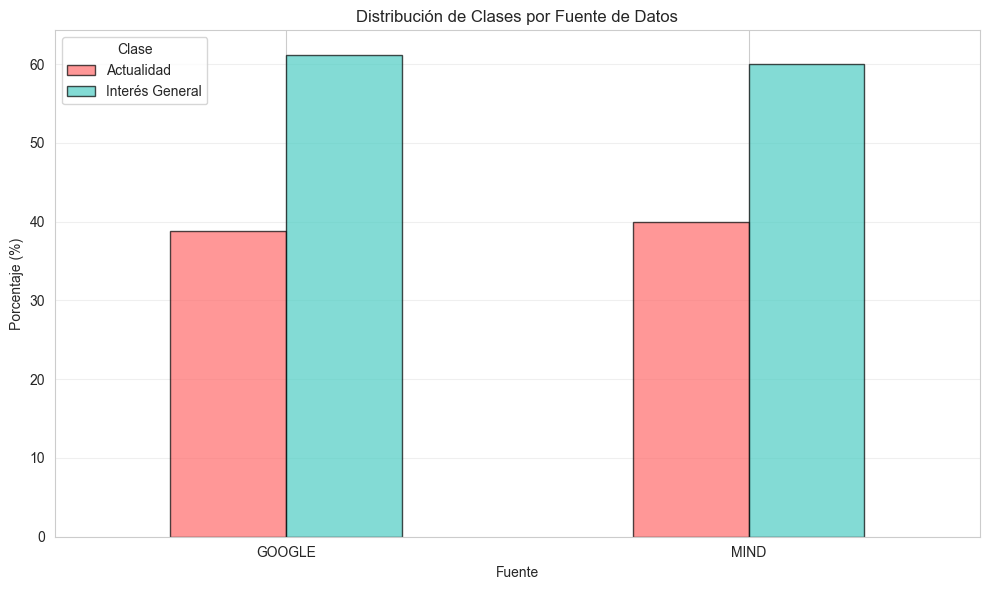


Gráfico guardado en: ../results/class_by_source.png


In [11]:
# Distribución de clases por fuente
cross_tab = pd.crosstab(df_clean['source'], df_clean['class_name'], margins=True)
print("=== DISTRIBUCIÓN DE CLASES POR FUENTE ===")
print(cross_tab)

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))
cross_tab_pct = pd.crosstab(df_clean['source'], df_clean['class_name'], normalize='index') * 100
cross_tab_pct.plot(kind='bar', ax=ax, color=['#FF6B6B', '#4ECDC4'], edgecolor='black', alpha=0.7)
ax.set_ylabel('Porcentaje (%)')
ax.set_xlabel('Fuente')
ax.set_title('Distribución de Clases por Fuente de Datos')
ax.legend(title='Clase')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../results/class_by_source.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGráfico guardado en: ../results/class_by_source.png")

## 9. Guardar Dataset Preprocesado

In [12]:
# Seleccionar columnas relevantes para el dataset final
df_final = df_clean[['doc_id', 'title_clean', 'label', 'class_name', 'source', 'category']].copy()

# Renombrar columna para claridad
df_final = df_final.rename(columns={'title_clean': 'text'})

# Guardar dataset preprocesado
output_path = '../data/processed/dataset_preprocessed.csv'
df_final.to_csv(output_path, index=False)
print(f"Dataset preprocesado guardado en: {output_path}")
print(f"Tamaño: {len(df_final):,} registros")
print(f"Columnas: {df_final.columns.tolist()}")

# Mostrar muestra del dataset final
print("\n=== MUESTRA DEL DATASET FINAL ===")
display(df_final.head(10))

Dataset preprocesado guardado en: ../data/processed/dataset_preprocessed.csv
Tamaño: 207,339 registros
Columnas: ['doc_id', 'text', 'label', 'class_name', 'source', 'category']

=== MUESTRA DEL DATASET FINAL ===


,doc_id,text,label,class_name,source,category
0,N88753,"The Brands Queen Elizabeth, Prince Charles, an...",1,Interés General,MIND,lifestyle
1,N45436,Walmart Slashes Prices on Last-Generation iPads,0,Actualidad,MIND,news
2,N23144,50 Worst Habits For Belly Fat,1,Interés General,MIND,health
3,N86255,Dispose of unwanted prescription drugs during ...,1,Interés General,MIND,health
4,N93187,The Cost of Trump's Aid Freeze in the Trenches...,0,Actualidad,MIND,news
5,N75236,I Was An NBA Wife. Here's How It Affected My M...,1,Interés General,MIND,health
6,N99744,"How to Get Rid of Skin Tags, According to a De...",1,Interés General,MIND,health
7,N5771,Check Houston traffic map for current road con...,1,Interés General,MIND,health
8,N124534,Should NFL be able to fine players for critici...,1,Interés General,MIND,sports
9,N51947,"How to record your screen on Windows, macOS, i...",0,Actualidad,MIND,news


## 10. Resumen del Preprocesamiento

In [13]:
print("="*60)
print("RESUMEN DEL PREPROCESAMIENTO")
print("="*60)
print(f"\n1. MAPEO DE CATEGORÍAS:")
print(f"   - Categorías originales mapeadas a 2 clases binarias")
print(f"   - Clase 0 (Actualidad): {len(actualidad_categories)} categorías")
print(f"   - Clase 1 (Interés General): {len(interes_general_categories)} categorías")

print(f"\n2. LIMPIEZA DE DATOS:")
print(f"   - Duplicados eliminados")
print(f"   - Texto normalizado y limpiado")
print(f"   - Registros con texto vacío eliminados")

print(f"\n3. DATASET FINAL:")
print(f"   - Total de registros: {len(df_final):,}")
print(f"   - Clase 0: {(df_final['label'] == 0).sum():,} ({(df_final['label'] == 0).sum()/len(df_final)*100:.2f}%)")
print(f"   - Clase 1: {(df_final['label'] == 1).sum():,} ({(df_final['label'] == 1).sum()/len(df_final)*100:.2f}%)")

print(f"\n4. PRÓXIMO PASO:")
print(f"   - Crear splits estratificados (70% train, 20% val, 10% test)")
print(f"   - Generar test_public.csv y test_labels.csv")
print("="*60)

RESUMEN DEL PREPROCESAMIENTO

1. MAPEO DE CATEGORÍAS:
   - Categorías originales mapeadas a 2 clases binarias
   - Clase 0 (Actualidad): 10 categorías
   - Clase 1 (Interés General): 16 categorías

2. LIMPIEZA DE DATOS:
   - Duplicados eliminados
   - Texto normalizado y limpiado
   - Registros con texto vacío eliminados

3. DATASET FINAL:
   - Total de registros: 207,339
   - Clase 0: 81,540 (39.33%)
   - Clase 1: 125,799 (60.67%)

4. PRÓXIMO PASO:
   - Crear splits estratificados (70% train, 20% val, 10% test)
   - Generar test_public.csv y test_labels.csv
